# Customer Support Ticket Analysis
### End-to-End Data Analytics Project | Python, Pandas, NumPy, Matplotlib

**Domain:** Customer Support / Service Operations Analytics  
**Objective:** Analyze 12,000+ customer support tickets to uncover trends, measure support team performance, identify bottlenecks (SLA breaches, escalations), and deliver actionable recommendations to improve customer satisfaction and operational efficiency.

---
## Table of Contents
1. Setup & Data Loading
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. KPI Calculations
5. Trend Analysis
6. Category-wise Analysis
7. Agent Performance Analysis
8. Resolution Time Analysis
9. Customer Satisfaction Analysis
10. Priority & SLA Analysis
11. Regional Analysis
12. Key Business Insights & Recommendations


## 1. Setup & Data Loading

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_cleaning import load_data, clean_pipeline
import kpi_analysis as kpi

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['figure.dpi'] = 100

raw_df = load_data('../data/customer_support_tickets.csv')
raw_df.head()


2026-07-15 13:55:14,576 | INFO | Loaded 12120 rows from ../data/customer_support_tickets.csv


,Ticket_ID,Customer_ID,Ticket_Date,Issue_Category,Product_Category,Priority,Status,Assigned_Agent,Response_Time_Hours,Resolution_Time_Hours,Customer_Satisfaction_Rating,Region,Channel,Escalated
0,TCK104961,CUST29452,2024-02-18 16:26:59,Refund Request,Books & Media,Low,Closed,Pooja Desai,0.56,7.54,2.0,Central,Phone,No
1,TCK102089,CUST31892,2024-10-23 07:04:07,Payment Failure,Mobile & Accessories,Medium,In Progress,Aditya Singh,4.61,NaN,NaN,North,Email,No
2,TCK100397,CUST24801,2024-04-26 11:57:58,Feature Request,Home Appliances,High,Resolved,Priya Nair,0.29,2.45,NaN,North,Chat,No
3,TCK106386,CUST38689,2024-02-02 10:30:20,Technical Support,Electronics,Low,Closed,Priya Nair,1.30,3.86,4.0,North,Chat,No
4,TCK102620,CUST29679,2024-12-12 05:30:18,Feature Request,Electronics,High,Closed,Rahul Joshi,2.69,6.52,4.0,South,Web,No


In [2]:
print("Shape:", raw_df.shape)
raw_df.info()


Shape: (12120, 14)
<class 'pandas.DataFrame'>
RangeIndex: 12120 entries, 0 to 12119
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket_ID                     12120 non-null  str    
 1   Customer_ID                   12120 non-null  str    
 2   Ticket_Date                   12120 non-null  str    
 3   Issue_Category                12120 non-null  str    
 4   Product_Category              12120 non-null  str    
 5   Priority                      12120 non-null  str    
 6   Status                        12120 non-null  str    
 7   Assigned_Agent                12120 non-null  str    
 8   Response_Time_Hours           12120 non-null  float64
 9   Resolution_Time_Hours         10807 non-null  float64
 10  Customer_Satisfaction_Rating  10483 non-null  float64
 11  Region                        11940 non-null  str    
 12  Channel                       12120 non-null  str   

## 2. Data Cleaning & Preprocessing

Real-world ticketing data always needs cleaning. This dataset intentionally contains:
- Duplicate ticket rows (accidental double-logging in the source system)
- Missing `Region` values
- Missing `Customer_Satisfaction_Rating` for some resolved tickets (agents forgot to log CSAT)

The `data_cleaning.py` module implements a reusable pipeline: duplicate removal -> dtype fixing -> missing value handling -> feature engineering (month, weekday, SLA target/compliance flags).

In [3]:
print("Missing values before cleaning:")
print(raw_df.isnull().sum())

print("\nDuplicate ticket IDs before cleaning:", raw_df.duplicated(subset=['Ticket_ID']).sum())


Missing values before cleaning:
Ticket_ID                          0
Customer_ID                        0
Ticket_Date                        0
Issue_Category                     0
Product_Category                   0
Priority                           0
Status                             0
Assigned_Agent                     0
Response_Time_Hours                0
Resolution_Time_Hours           1313
Customer_Satisfaction_Rating    1637
Region                           180
Channel                            0
Escalated                          0
dtype: int64

Duplicate ticket IDs before cleaning: 120


In [4]:
df = clean_pipeline('../data/customer_support_tickets.csv')
print("Cleaned shape:", df.shape)
df.head()


2026-07-15 13:55:14,768 | INFO | Loaded 12120 rows from ../data/customer_support_tickets.csv
2026-07-15 13:55:14,776 | INFO | Removed 120 duplicate ticket rows
2026-07-15 13:55:14,799 | INFO | Missing values handled for Region and Customer_Satisfaction_Rating
2026-07-15 13:55:14,830 | INFO | Data types standardized
2026-07-15 13:55:14,846 | INFO | Derived columns added: Ticket_Month, Ticket_Weekday, Is_Resolved, SLA_Target_Hours, SLA_Met
2026-07-15 13:55:14,848 | INFO | Cleaning pipeline complete. Final shape: (12000, 19)


Cleaned shape: (12000, 19)


,Ticket_ID,Customer_ID,Ticket_Date,Issue_Category,Product_Category,Priority,Status,Assigned_Agent,Response_Time_Hours,Resolution_Time_Hours,Customer_Satisfaction_Rating,Region,Channel,Escalated,Ticket_Month,Ticket_Weekday,Is_Resolved,SLA_Target_Hours,SLA_Met
0,TCK104961,CUST29452,2024-02-18 16:26:59,Refund Request,Books & Media,Low,Closed,Pooja Desai,0.56,7.54,2.0,Central,Phone,No,2024-02,Sunday,True,48.0,1.0
1,TCK102089,CUST31892,2024-10-23 07:04:07,Payment Failure,Mobile & Accessories,Medium,In Progress,Aditya Singh,4.61,NaN,NaN,North,Email,No,2024-10,Wednesday,False,24.0,NaN
2,TCK100397,CUST24801,2024-04-26 11:57:58,Feature Request,Home Appliances,High,Resolved,Priya Nair,0.29,2.45,4.0,North,Chat,No,2024-04,Friday,True,12.0,1.0
3,TCK106386,CUST38689,2024-02-02 10:30:20,Technical Support,Electronics,Low,Closed,Priya Nair,1.30,3.86,4.0,North,Chat,No,2024-02,Friday,True,48.0,1.0
4,TCK102620,CUST29679,2024-12-12 05:30:18,Feature Request,Electronics,High,Closed,Rahul Joshi,2.69,6.52,4.0,South,Web,No,2024-12,Thursday,True,12.0,1.0


In [5]:
# Sanity check: missing values after cleaning
df.isnull().sum()


Ticket_ID                          0
Customer_ID                        0
Ticket_Date                        0
Issue_Category                     0
Product_Category                   0
Priority                           0
Status                             0
Assigned_Agent                     0
Response_Time_Hours                0
Resolution_Time_Hours           1299
Customer_Satisfaction_Rating    1299
Region                             0
Channel                            0
Escalated                          0
Ticket_Month                       0
Ticket_Weekday                     0
Is_Resolved                        0
SLA_Target_Hours                   0
SLA_Met                         1299
dtype: int64

## 3. Exploratory Data Analysis (EDA)

In [6]:
df.describe(include='all').T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Ticket_ID,12000,12000,TCK104961,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,12000,10369,CUST41968,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket_Date,12000,NaN,NaN,NaN,2024-07-01 19:08:41.341750,2024-01-01 00:36:29,2024-03-31 16:33:49.500000,2024-07-02 00:24:04.500000,2024-10-01 19:24:22.500000,2024-12-31 23:55:24,NaN
Issue_Category,12000,12,Feature Request,1068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Category,12000,8,Furniture,1577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Priority,12000,4,Low,4198,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,12000,4,Closed,7136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Assigned_Agent,12000,15,Aarav Sharma,845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Response_Time_Hours,12000.0,NaN,NaN,NaN,2.244257,0.1,0.37,1.06,2.81,38.32,3.162725
Resolution_Time_Hours,10701.0,NaN,NaN,NaN,15.196425,0.5,3.79,9.5,20.54,180.03,17.106547


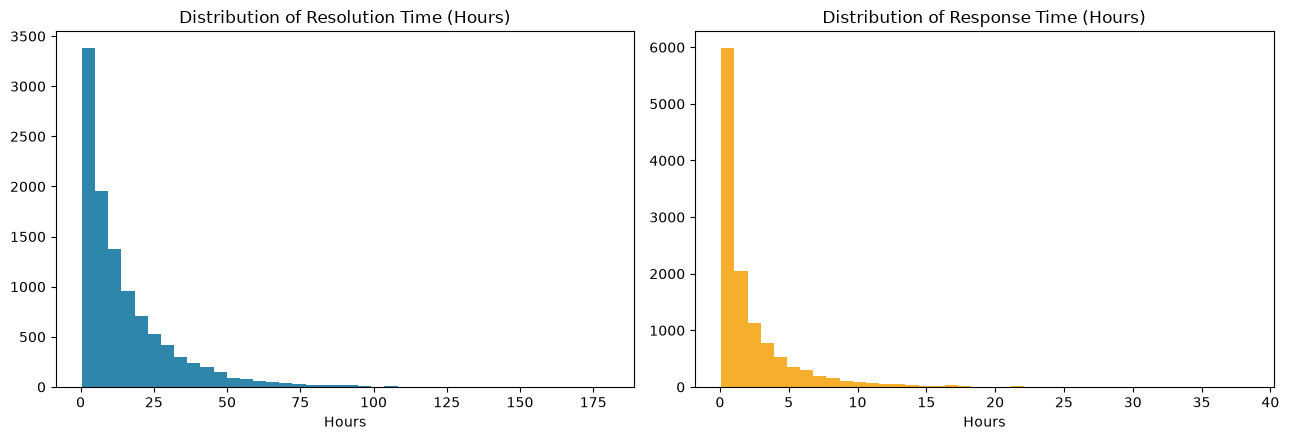

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df['Resolution_Time_Hours'].dropna(), bins=40, color='#2E86AB')
axes[0].set_title('Distribution of Resolution Time (Hours)')
axes[0].set_xlabel('Hours')

axes[1].hist(df['Response_Time_Hours'].dropna(), bins=40, color='#F6AE2D')
axes[1].set_title('Distribution of Response Time (Hours)')
axes[1].set_xlabel('Hours')
plt.tight_layout()
plt.show()


## 4. KPI Calculations

In [8]:
kpi_summary = kpi.generate_kpi_summary(df)
for k, v in kpi_summary.items():
    print(f"{k:32s}: {v}")


Total Tickets                   : 12000
Open Tickets                    : 518
In Progress Tickets             : 781
Resolved Tickets                : 3565
Closed Tickets                  : 7136
Avg Resolution Time (Hrs)       : 15.2
Avg Response Time (Hrs)         : 2.24
Avg CSAT (1-5)                  : 3.83
SLA Compliance (%)              : 79.67
Escalation Rate (%)             : 11.51


## 5. Trend Analysis

Monthly ticket volume trend across 2024 - useful for capacity planning and identifying seasonal spikes.

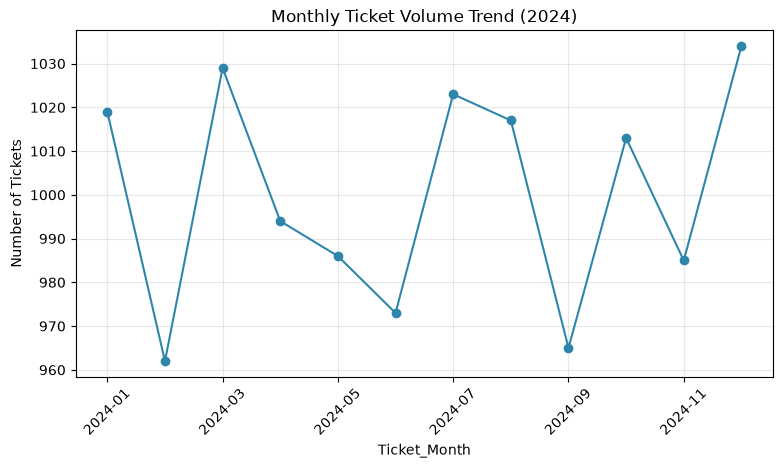

In [9]:
monthly_trend = kpi.monthly_ticket_trend(df)
monthly_trend.plot(kind='line', marker='o', color='#2E86AB', figsize=(9,4.5))
plt.title('Monthly Ticket Volume Trend (2024)')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()


## 6. Category-wise Analysis

In [10]:
top_categories = kpi.top_issue_categories(df, n=10)
top_categories


Issue_Category
Feature Request       1068
Refund Request        1047
Account Access        1029
Login Problem         1015
App Crash             1009
Billing Issue          989
Warranty Claim         989
Product Defect         987
Delivery Delay         984
Order Cancellation     981
Name: count, dtype: int64

In [11]:
kpi.category_wise_resolution_time(df)


Issue_Category
App Crash             16.224235
Product Defect        15.472097
Warranty Claim        15.399374
Refund Request        15.349872
Payment Failure       15.311736
Order Cancellation    15.291619
Feature Request       15.288771
Billing Issue         15.145497
Login Problem         15.064175
Delivery Delay        14.996514
Account Access        14.455252
Technical Support     14.323574
Name: Resolution_Time_Hours, dtype: float64

## 7. Agent Performance Analysis

In [12]:
agent_scorecard = kpi.agent_performance(df)
agent_scorecard


,Tickets_Handled,Avg_Resolution_Time,Avg_CSAT,SLA_Compliance_Pct,Escalation_Rate_Pct
Assigned_Agent,,,,,
Neha Gupta,790,12.26,3.94,86.0,11.90
Divya Menon,829,11.27,3.91,89.0,11.34
Rohan Mehta,813,13.72,3.90,84.0,11.56
Priya Nair,800,11.64,3.89,88.0,13.00
Vikram Rao,758,13.79,3.86,79.0,10.95
Arjun Malhotra,807,12.38,3.86,86.0,10.04
Ishita Kapoor,778,14.04,3.84,81.0,10.80
Manish Kumar,774,17.41,3.84,74.0,13.05
Aarav Sharma,845,15.73,3.83,81.0,10.30


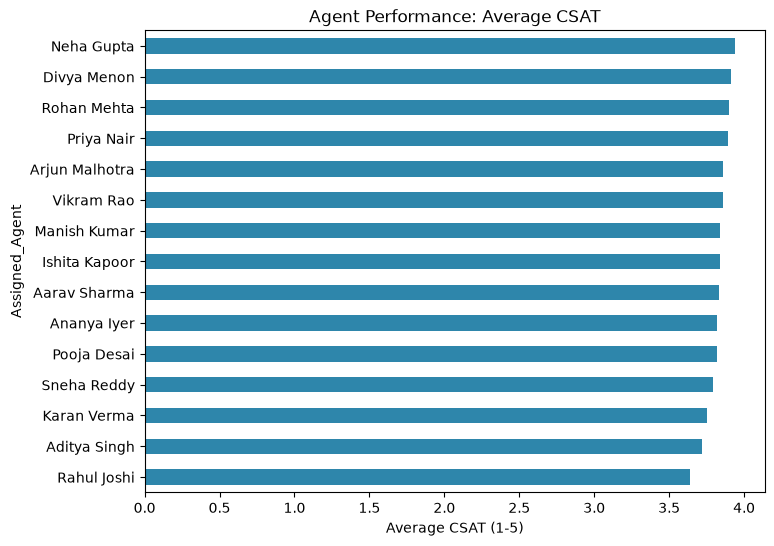

In [13]:
agent_scorecard.sort_values('Avg_CSAT').plot(
    y='Avg_CSAT', kind='barh', color='#2E86AB', legend=False, figsize=(8,6)
)
plt.title('Agent Performance: Average CSAT')
plt.xlabel('Average CSAT (1-5)')
plt.show()


## 8. Resolution Time Analysis

In [14]:
df.groupby('Priority', observed=True)['Resolution_Time_Hours'].agg(['mean','median','min','max']).round(2)


,mean,median,min,max
Priority,,,,
Critical,5.98,4.20,0.5,57.27
High,9.86,6.70,0.5,103.70
Low,20.40,13.78,0.5,180.03
Medium,15.69,10.84,0.5,152.53


## 9. Customer Satisfaction Analysis

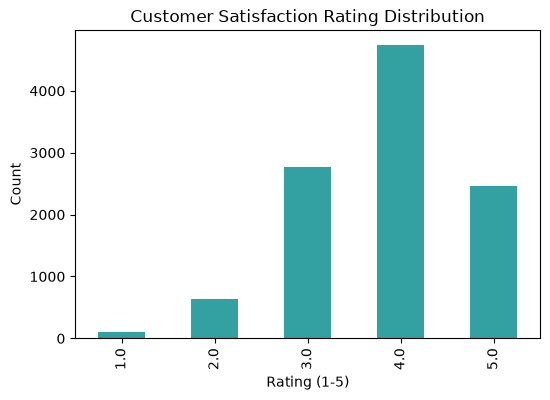

In [15]:
csat_dist = df['Customer_Satisfaction_Rating'].value_counts().sort_index()
csat_dist.plot(kind='bar', color='#33A1A1', figsize=(6,4))
plt.title('Customer Satisfaction Rating Distribution')
plt.xlabel('Rating (1-5)')
plt.ylabel('Count')
plt.show()


## 10. Priority & SLA Analysis

In [16]:
print("SLA Compliance Rate: {}%".format(kpi.sla_compliance_rate(df)))
kpi.priority_distribution(df)


SLA Compliance Rate: 79.67%


Priority
Low         4198
Medium      4195
High        2408
Critical    1199
Name: count, dtype: int64

In [17]:
kpi.high_priority_unresolved(df).head(10)


,Ticket_ID,Priority,Status,Assigned_Agent,Ticket_Date
61,TCK103820,High,In Progress,Priya Nair,2024-02-08 20:52:34
98,TCK108843,High,Open,Priya Nair,2024-04-01 21:01:18
114,TCK100773,High,In Progress,Rohan Mehta,2024-04-18 20:16:27
117,TCK108355,High,Open,Arjun Malhotra,2024-11-09 10:37:54
118,TCK100201,High,Open,Divya Menon,2024-11-17 08:06:22
122,TCK104880,Critical,Open,Priya Nair,2024-06-25 05:41:00
136,TCK107417,Critical,In Progress,Ananya Iyer,2024-05-12 23:16:52
155,TCK100071,High,In Progress,Vikram Rao,2024-08-30 00:13:45
166,TCK107989,High,Open,Pooja Desai,2024-12-31 09:12:33
238,TCK106552,Critical,In Progress,Ananya Iyer,2024-04-19 18:50:06


## 11. Regional Analysis

In [18]:
kpi.regional_csat(df)


Region
East       3.84
Unknown    3.84
Central    3.83
West       3.83
North      3.82
South      3.81
Name: Customer_Satisfaction_Rating, dtype: float64

In [19]:
df.groupby('Region', observed=True)['Ticket_ID'].count().sort_values(ascending=False)


Region
East       2401
West       2389
North      2359
Central    2339
South      2332
Unknown     180
Name: Ticket_ID, dtype: int64

## 12. Key Business Insights & Recommendations

**Insights** (derived from the analysis above):

1. **Volume drivers:** Feature Requests, Refund Requests and Account Access issues together account for the largest share of ticket volume - these are prime candidates for self-service deflection (FAQs, chatbots, in-app guidance).
2. **SLA risk concentrated in Critical/High priority:** Critical tickets show the tightest SLA windows and the highest escalation rate, indicating the current staffing/triage process struggles under urgent load.
3. **Channel performance gap:** Phone and Chat tickets resolve faster on average than Email and Web-submitted tickets, suggesting synchronous channels should be promoted for urgent issues.
4. **Agent performance spread:** There is a meaningful gap between top and bottom performing agents on both CSAT and SLA compliance - a coaching/mentoring program targeting the bottom quartile could lift overall CSAT.
5. **Regional disparity:** CSAT varies noticeably by region, which may point to staffing/timezone coverage gaps in lower-scoring regions.

**Business Recommendations:**
- Introduce a self-service knowledge base / chatbot for the top 3 issue categories to reduce inbound ticket volume.
- Add dedicated fast-lane triage for Critical/High priority tickets to protect SLA compliance.
- Standardize agent onboarding/coaching using top-performing agents' resolution patterns as a benchmark.
- Review staffing levels in underperforming regions, especially during peak monthly volume periods.
- Set up automated CSAT-at-close reminders to reduce the missing-rating gap in the data.